In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_glass_data

df = load_glass_data(target="Density293K")
print(f"Shape: {df.shape}")
print(f"\nFeatures: {df.columns.tolist()}")

Shape: (61157, 22)

Features: ['SiO2', 'P2O5', 'ZrO2', 'Na2O', 'Al2O3', 'Fe2O3', 'CaO', 'MgO', 'K2O', 'B2O3', 'BaO', 'ZnO', 'Li2O', 'SrO', 'SnO2', 'La2O3', 'TiO2', 'PbO', 'Bi2O3', 'TeO2', 'other_compounds', 'Density293K']


count    61157.000000
mean         3.094862
std          1.074865
min          1.061684
25%          2.460000
50%          2.645000
75%          3.307000
max         10.523768
Name: Density293K, dtype: float64


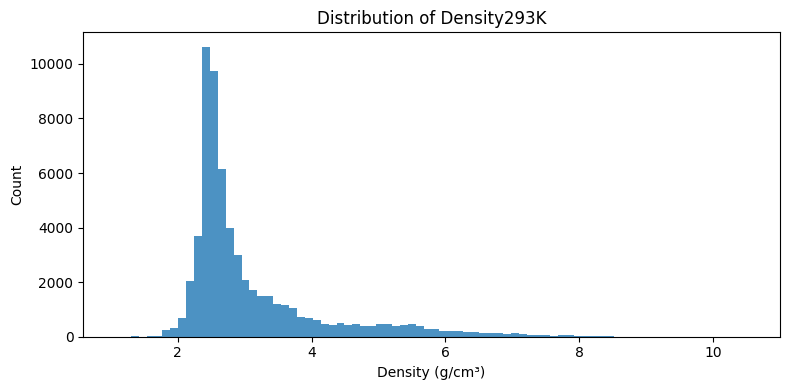

In [2]:
print(df["Density293K"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["Density293K"], bins=80, edgecolor="none", alpha=0.8)
plt.xlabel("Density (g/cm³)")
plt.ylabel("Count")
plt.title("Distribution of Density293K")
plt.tight_layout()
plt.savefig("../outputs/density_distribution.png", dpi=150)
plt.show()

count    61157.00000
mean         1.01902
std          2.37214
min          0.00000
25%          0.00000
50%          0.00000
75%          0.26000
max         10.00000
Name: other_compounds, dtype: float64


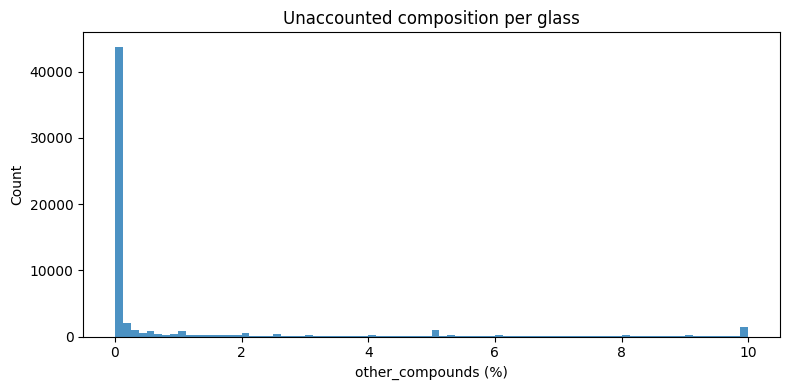

In [3]:
print(df["other_compounds"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["other_compounds"], bins=80, edgecolor="none", alpha=0.8)
plt.xlabel("other_compounds (%)")
plt.ylabel("Count")
plt.title("Unaccounted composition per glass")
plt.tight_layout()
plt.savefig("../outputs/density_other_compounds.png", dpi=150)
plt.show()

In [4]:
oxide_cols = [c for c in df.columns if c not in ["other_compounds", "Density293K"]]

presence = (df[oxide_cols] > 0).mean().sort_values(ascending=False)
mean_when_present = df[oxide_cols].replace(0, float("nan")).mean().sort_values(ascending=False)

summary = pd.DataFrame({
    "presence_%": (presence * 100).round(2),
    "mean_when_present": mean_when_present.round(2),
}).sort_values("presence_%", ascending=False)

print(summary)

       presence_%  mean_when_present
SiO2        67.94              58.23
B2O3        48.19              29.72
Al2O3       46.47               9.16
Na2O        45.25              13.77
CaO         36.84              11.72
MgO         28.72               8.62
K2O         26.50               7.36
BaO         21.48              12.23
Li2O        18.97              15.92
P2O5        17.03              39.10
ZnO         15.46              16.13
SrO         15.31               6.66
TiO2        13.43               9.17
ZrO2        12.97               2.36
PbO         10.90              27.15
Fe2O3        9.60               4.28
SnO2         9.31               0.19
La2O3        6.88               7.21
Bi2O3        5.54              28.20
TeO2         4.68              65.30


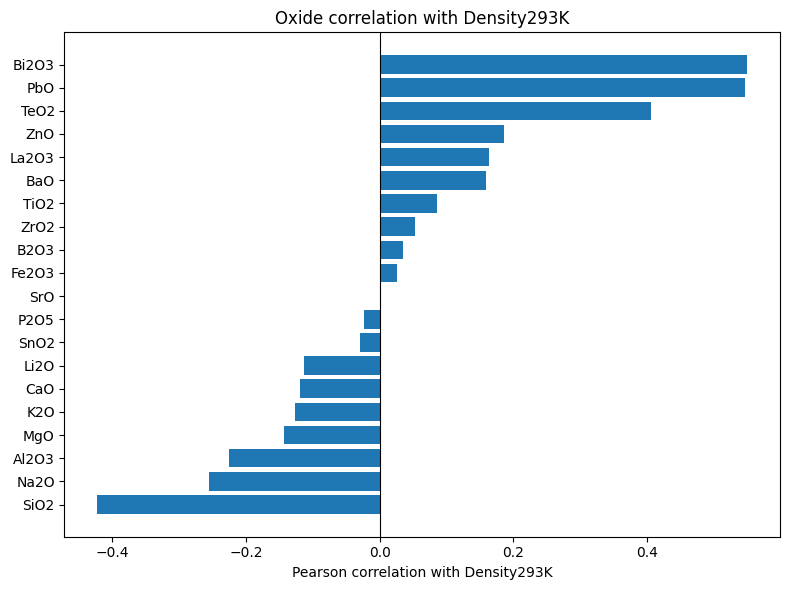

In [5]:
oxide_cols = [c for c in df.columns if c not in ["other_compounds", "Density293K"]]

correlations = df[oxide_cols].corrwith(df["Density293K"]).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(correlations.index, correlations.values)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Pearson correlation with Density293K")
plt.title("Oxide correlation with Density293K")
plt.tight_layout()
plt.savefig("../outputs/density_correlations.png", dpi=150)
plt.show()

## Key findings

### Dataset
- 61,157 glasses after filtering (90% coverage threshold, 20 oxide features)
- More data than Tg (49,972) — more glasses have density measured
- Different feature set than Tg: has Fe2O3, SnO2 but missing Nb2O5, WO3, Sb2O3
- 75% of glasses have <0.26% unaccounted composition — very clean
- Density range: 1.06–10.52 g/cm³, median 2.645 g/cm³

### Oxide composition patterns
- **SiO2** dominates even more than in Tg — 68% presence, averaging 58% of composition
- **TeO2** barely made the 5% threshold (4.68%) — tellurite glasses are a small subset here
- **SnO2** present in 9% of glasses but only 0.19% average — used as a fining agent, not a network former
- **P2O5 and Bi2O3** average 39% and 28% when present — phosphate and bismuth glass families

### Correlations with Density293K
- **Bi2O3 and PbO strongly positive** — very heavy elements (atomic mass ~207-209), directly increase density
- **TeO2 positive** — tellurium is also a heavy element
- **SiO2 strongly negative** — silica is light, high SiO2 dilutes density
- **Na2O, Al2O3 negative** — light elements, lower density when dominant
- Density correlations are more directly driven by atomic mass than Tg correlations — simpler physical mechanism

### Comparison with Tg
- Tg is controlled by network structure (how connected the glass network is)
- Density is controlled more directly by atomic mass of constituent oxides
- This suggests density may be easier to predict — more linear relationships expected